# 03 — How I built the inference pipeline

This notebook explains how I ask three open-weights VLMs my 4,021 questions, and why the pipeline is built the way it is. Everything here runs on my laptop: the prompts, the schema and the scoring are all testable without a GPU, which is the point — I only rent hardware once I know the pipeline is right.

Code: `src/vlm_parking/prompts.py` and `scripts/run_inference.py`.

**The experiment in one table**

| | Condition A | Condition B |
|---|---|---|
| The model sees | the sign crop + the question | my transcription of the sign + the question |
| Must do | read **and** reason | reason only |
| Measures | end-to-end accuracy | the reasoning ceiling |

**A − B is the headline number: how much accuracy is lost to reading the sign.**

In [8]:
import sys
from pathlib import Path

SRC = Path("../src").resolve()          # import vlm_parking even if this kernel isn't the project venv
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import json
from pathlib import Path

import pandas as pd
from PIL import Image

from vlm_parking.prompts import Answer, build_prompt, render_sign
from vlm_parking.schema import Query, Sign

DATA = Path("../data")
signs = pd.read_parquet(DATA / "queries/signs_v1.parquet")
queries = pd.read_parquet(DATA / "queries/queries_v1.parquet")
print(f"{len(signs)} signs, {len(queries):,} queries, {len(queries) / len(signs):.1f} per sign")

272 signs, 4,021 queries, 14.8 per sign


## 1. One prompt, two conditions

The only thing that differs between conditions is how the sign is presented. Everything else — task statement, wording of the question, the output schema — is byte-identical, and a test enforces that (`tests/test_prompts.py`). If the two prompts differed in any other way, the A−B gap would be measuring my prompt writing rather than the models' perception.

The prompt states the rules that my evaluator applies, because I'm testing whether a model can apply *posted* rules, not whether it guesses my conventions: the stay must be legal from arrival to departure, a restriction starting exactly at departure doesn't count, panels are numbered from the top, meters are assumed paid, and it isn't a holiday.

There is deliberately **no primer on LA sign conventions**. Whether such a primer helps is one of the extensions; leaving it out keeps the MVP clean.

In [9]:
q_row = queries[(queries.n_panels >= 3) & (queries.type == "clear_illegal")].iloc[0]
sign = Sign(**json.loads(signs[signs.sign_id == q_row.sign_id].iloc[0].sign_json))
query = Query(day=q_row.day, time=q_row.time, duration_min=int(q_row.duration_min),
              permit_district=q_row.permit_district if isinstance(q_row.permit_district, str) else None)

print("=== CONDITION A (the crop is attached as an image) ===")
print(build_prompt(query))

=== CONDITION A (the crop is attached as an image) ===
You are given a Los Angeles parking sign and a parking question.

Decide whether parking is legal for the ENTIRE stay described in the question.
- The stay must be legal from arrival until departure; if any part of it breaks a posted rule, it is illegal.
- A restriction that starts exactly when the driver leaves does not make the stay illegal.
- Panels are numbered from the top of the sign, starting at 0.
- Assume the driver pays any meter, the day is not a holiday, and no rule applies except what the sign posts.

Answer with JSON only: {"reason": "...", "governing_panel": <int or null>, "verdict": "legal" | "illegal"}.

The sign is shown in the image.

Question: A driver arrives on Monday at 14:19 and wants to park for 3 hours. The driver has no parking permit. Is parking legal?


In [10]:
print("=== CONDITION B (same prompt, sign given as text) ===")
print(build_prompt(query, sign))
print("\nground truth:", q_row.verdict, "| governing panel:", q_row.governing_panel, "|", q_row.reason)

=== CONDITION B (same prompt, sign given as text) ===
You are given a Los Angeles parking sign and a parking question.

Decide whether parking is legal for the ENTIRE stay described in the question.
- The stay must be legal from arrival until departure; if any part of it breaks a posted rule, it is illegal.
- A restriction that starts exactly when the driver leaves does not make the stay illegal.
- Panels are numbered from the top of the sign, starting at 0.
- Assume the driver pays any meter, the day is not a holiday, and no rule applies except what the sign posts.

Answer with JSON only: {"reason": "...", "governing_panel": <int or null>, "verdict": "legal" | "illegal"}.

The sign has the following panels, top to bottom:
Panel 0: No parking; 02:00-06:00; every day
Panel 1: No parking; 08:00-10:00; Monday
Panel 2: Time-limited parking; limit 120 minutes; 08:00-18:00; every day

Question: A driver arrives on Monday at 14:19 and wants to park for 3 hours. The driver has no parking permi

condition A sees this crop, 76x344 px:


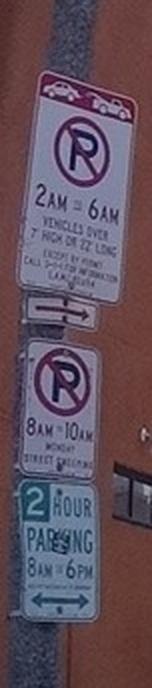

In [11]:
im = Image.open(DATA / "collect" / signs[signs.sign_id == q_row.sign_id].iloc[0].crop_path)
print(f"condition A sees this crop, {im.size[0]}x{im.size[1]} px:")
im.resize((im.width * 2, im.height * 2), Image.LANCZOS)

## 2. Rendering a sign as text

Condition B needs my structured transcription turned back into prose. I keep it flat and mechanical — one line per panel, fields in a fixed order — so that no phrasing choice of mine does the model's reasoning for it. I spell out the overnight case, because "18:00-08:00" is exactly the kind of thing a model might read backwards, and I want B to test reasoning rather than my formatting.

One caveat I'll state in the writeup: this representation is *easier* than a raw transcript of the sign's words, because it's already parsed into panels, days and 24-hour times. So the A−B gap measures "perception plus parsing into structure", not perception alone.

In [12]:
for sid in signs.sort_values("n_panels", ascending=False).sign_id.head(2):
    s = Sign(**json.loads(signs[signs.sign_id == sid].iloc[0].sign_json))
    print(sid); print(render_sign(s)); print()

downtown/470217334091689_0
The sign has the following panels, top to bottom:
Panel 0: No stopping; 07:00-09:00; Monday, Tuesday, Wednesday, Thursday, Friday
Panel 1: No stopping; 16:00-18:00; Monday, Tuesday, Wednesday, Thursday, Friday
Panel 2: Time-limited parking; limit 120 minutes; 09:00-16:00; Monday, Tuesday, Wednesday, Thursday, Friday
Panel 3: Time-limited parking; limit 120 minutes; 18:00-20:00; Monday, Tuesday, Wednesday, Thursday, Friday
Panel 4: Time-limited parking; limit 120 minutes; 08:00-20:00; Saturday

downtown/494917368627113_0
The sign has the following panels, top to bottom:
Panel 0: No stopping; 07:00-09:00; Monday, Tuesday, Wednesday, Thursday, Friday
Panel 1: No stopping; 16:00-18:00; Monday, Tuesday, Wednesday, Thursday, Friday
Panel 2: Time-limited parking; limit 120 minutes; 09:00-16:00; Monday, Tuesday, Wednesday, Thursday, Friday
Panel 3: Time-limited parking; limit 120 minutes; 18:00-20:00; Monday, Tuesday, Wednesday, Thursday, Friday
Panel 4: Time-limited

## 3. The answer schema

I decode against a JSON schema, so parsing can't fail on prose. Field order matters because generation is left to right:

1. `reason` — one or two sentences. Writing it first lets the model work through the rule before committing, and it gives me text for the error taxonomy in Phase 6.
2. `governing_panel` — which panel decides it, or null. This is my rule-attribution metric: a model can be right for the wrong reason, and I want to count that.
3. `verdict` — `legal` or `illegal`.

I left `ambiguous` out of the model's options on purpose: ambiguous signs generate no queries, so every question has a definite answer.

In [15]:
print(json.dumps(Answer.model_json_schema()["properties"], indent=1))
good = Answer.model_validate_json('{"reason": "Street cleaning applies 8-10 on Monday.", "governing_panel": 0, "verdict": "illegal"}')
print("\nparsed:", good.model_dump())
for bad in ['{"reason": "x", "governing_panel": 0, "verdict": "maybe"}', "I'd say it's fine."]:
    try:
        Answer.model_validate_json(bad)
    except Exception as e:
        print(f"rejected {bad[:40]!r}: {type(e).__name__}")

{
 "reason": {
  "description": "One or two sentences: which posted rule decides this.",
  "maxLength": 300,
  "title": "Reason",
  "type": "string"
 },
 "governing_panel": {
  "anyOf": [
   {
    "type": "integer"
   },
   {
    "type": "null"
   }
  ],
  "description": "0-based index from the top of the sign of the panel that decides it; null if parking is legal.",
  "title": "Governing Panel"
 },
 "verdict": {
  "description": "Is parking legal for the whole stay?",
  "enum": [
   "legal",
   "illegal"
  ],
  "title": "Verdict",
  "type": "string"
 }
}

parsed: {'reason': 'Street cleaning applies 8-10 on Monday.', 'governing_panel': 0, 'verdict': 'illegal'}
rejected '{"reason": "x", "governing_panel": 0, "v': ValidationError
rejected "I'd say it's fine.": ValidationError


## 4. Choices that make the run reproducible

- **Guided JSON decoding** (vLLM): at each step the engine only allows tokens that can still complete valid JSON for my schema. Parse failures should be ~0; the plan's gate is under 1%, and I report whatever it is.
- **temperature 0**, fixed seed, `max_tokens 200`. Greedy decoding isn't bit-exact on GPUs — floating-point addition isn't associative and kernels vary with batch composition — so I also cache every answer.
- **A cache keyed on everything that could change an answer:** model id, condition, a hash of the exact image bytes or rendered sign text, the prompt, and the sampling settings. Re-running resumes for free; changing the resize policy or the prompt invalidates the affected entries automatically.
- **Results stream to JSONL** as they arrive, so a crashed pod costs minutes, not a run.
- **The image goes first in the prompt.** Each sign is asked ~15 questions, so putting the image before the question gives a long shared prefix that vLLM's prefix cache reuses across all of them.

## 5. Image policy

One fixed rule for every model: longest side capped at 1024 px, JPEG quality 95, **no upscaling**. Then each model applies its own scheme — Qwen keeps native resolution, InternVL tiles at 448 px, MiniCPM slices and resamples — and I record tokens per image so I can tell whether a model is disadvantaged by its own tiling rather than by its eyesight.

I chose not to upscale small crops: enlarging adds no information, and it would hide the fact that some signs really are small in the source photo. My crops are small: a median of 242 px tall in the original photo.

In [16]:
px = signs.height_native
print("sign height in the original photo (px):", {k: round(v) for k, v in px.describe(percentiles=[.1, .5, .9]).items()})

def qwen_tokens(w, h, per=32, min_px=256 * 32 * 32, max_px=1280 * 32 * 32):
    # native resolution: ~1 token per 32x32 px after 2x2 merging, with the processor's own
    # min/max pixel clamp (it upscales small crops) [VERIFY against each model's processor config]
    scale = (min_px / (w * h)) ** 0.5 if w * h < min_px else (max_px / (w * h)) ** 0.5 if w * h > max_px else 1.0
    return max(1, round(w * scale / per)) * max(1, round(h * scale / per))

def internvl_tokens(w, h, tile=448, per_tile=256, max_tiles=12):  # tiles + a thumbnail
    grids = [(c, r) for c in range(1, max_tiles + 1) for r in range(1, max_tiles + 1) if c * r <= max_tiles]
    c, r = min(grids, key=lambda g: (abs(w / h - g[0] / g[1]), -g[0] * g[1]))
    n = c * r
    return (n + (1 if n > 1 else 0)) * per_tile

rows = []
for sid in signs.sign_id.sample(200, random_state=0):
    im = Image.open(DATA / "collect" / signs[signs.sign_id == sid].iloc[0].crop_path)
    w, h = im.size
    if max(w, h) > 1024:
        s = 1024 / max(w, h); w, h = round(w * s), round(h * s)
    rows.append({"w": w, "h": h, "qwen": qwen_tokens(w, h), "internvl": internvl_tokens(w, h)})
tok = pd.DataFrame(rows)
print("\nestimated visual tokens per image (200-sign sample):")
print(tok[["qwen", "internvl"]].describe(percentiles=[.5]).round(0).to_string())
print("\nInternVL's tiling costs roughly", round(tok.internvl.median() / tok.qwen.median(), 1),
      "x Qwen's tokens for the same crop. Both schemes end up spending far more tokens than the crop's")
print("own pixel count implies, because each upscales or tiles a small image up to its preferred size.")

sign height in the original photo (px): {'count': 272, 'mean': 292, 'std': 167, 'min': 79, '10%': 135, '50%': 242, '90%': 514, 'max': 1150}

estimated visual tokens per image (200-sign sample):
        qwen  internvl
count  200.0     200.0
mean   259.0    2638.0
std     21.0     659.0
min    240.0    1280.0
50%    253.0    2816.0
max    408.0    3328.0

InternVL's tiling costs roughly 11.1 x Qwen's tokens for the same crop. Both schemes end up spending far more tokens than the crop's
own pixel count implies, because each upscales or tiles a small image up to its preferred size.


## 6. Why vLLM, and why not my laptop

I tried to price running this on my M3 Pro. It doesn't work well:

- vLLM has no Apple Silicon backend, so I'd need MLX or llama.cpp, losing guided decoding, continuous batching and prefix caching;
- an 8B model in bf16 is ~16 GB of weights, so I'd have to quantize to 4-bit, which mixes quantization damage into my perception result;
- and at roughly 10–20 s per image query, condition A alone would take 11–22 hours **per model**.

A rented GPU runs the whole 3 × 2 matrix in a few hours for a few dollars, at bf16, with the harness exactly as written.

**Hardware:** A100 40 GB (SXM4) rather than the A10 24 GB. The A100 is about 2–2.5× faster, and 24 GB is tight once InternVL's ~3k visual tokens per image start filling the KV cache. Total cost should be $5–8, well inside the plan's $20–40 budget.

In [17]:
weights_gb = 8.2 * 2  # 8.2B params in bf16
kv_per_token_kb = 2 * 36 * 8 * 128 * 2 / 1024  # layers x kv-heads x head-dim, bf16
for gpu, mem in [("A10 24GB", 24), ("A100 40GB", 40)]:
    free = mem * 0.9 - weights_gb - 2
    tokens = free * 1e6 / kv_per_token_kb
    print(f"{gpu:<10} ~{free:4.1f} GB for KV cache -> ~{tokens/1e3:,.0f}k tokens "
          f"-> ~{tokens / 1500:,.0f} concurrent image queries")

A10 24GB   ~ 3.2 GB for KV cache -> ~22k tokens -> ~15 concurrent image queries
A100 40GB  ~17.6 GB for KV cache -> ~122k tokens -> ~81 concurrent image queries


## 7. Running it

```bash
# 1. sanity check, no GPU needed: builds every prompt and writes them out
uv run python scripts/run_inference.py --model qwen3-vl-8b --condition A --dry-run

# 2. on the pod: smoke test first (20 queries, text-only, seconds)
uv run python scripts/run_inference.py --model qwen3-vl-8b --condition B --limit 20

# 3. the cheap half of the matrix
for m in qwen3-vl-8b internvl3_5-8b minicpm-v-4_5; do
  uv run python scripts/run_inference.py --model $m --condition B
done

# 4. the expensive half
for m in qwen3-vl-8b internvl3_5-8b minicpm-v-4_5; do
  uv run python scripts/run_inference.py --model $m --condition A
done
```

Order matters: condition B is text-only and fast, so if the prompt, schema or parsing is wrong I find out in minutes rather than after an hour of image inference. The run script prints the parse-failure rate and mean prompt tokens at the end of every run, which are my two gates.

## 8. Scoring, before I have any results

I can write and test the scoring against fake answers, which is also how I know what "good" looks like. The base rate is 44.1% legal, so always answering "illegal" scores 55.9% — any model that can't beat that has told me nothing.

In [18]:
baseline = queries.verdict.value_counts(normalize=True)
print("base rate:", baseline.round(3).to_dict())
print("majority-class baseline:", f"{baseline.max():.1%}")
print("\nby panel count:")
print(queries.groupby(queries.n_panels.clip(upper=3)).verdict.value_counts(normalize=True).unstack().round(3).to_string())
print("\nby query type:")
print(queries.groupby("type").verdict.value_counts(normalize=True).unstack(fill_value=0).round(3).to_string())

base rate: {'illegal': 0.566, 'legal': 0.434}
majority-class baseline: 55.9%

by panel count:
verdict   illegal  legal
n_panels                
1           0.596  0.404
2           0.510  0.490
3           0.515  0.485

by query type:
verdict            illegal  legal
type                             
boundary             0.428  0.572
clear_illegal        1.000  0.000
clear_legal          0.000  1.000
permit               0.500  0.500
permit_irrelevant    0.566  0.434


In [19]:
import numpy as np

# a fake model: right on clear queries, coin-flips on boundaries, and fooled by permit mentions
rng = np.random.default_rng(0)
fake = queries.copy()
fake["pred"] = fake.verdict
flip = (fake.type == "boundary") & (rng.random(len(fake)) < 0.5)
fake.loc[flip, "pred"] = np.where(fake.loc[flip, "verdict"] == "legal", "illegal", "legal")
fooled = (fake.type == "permit_irrelevant") & fake.permit_district.notna() & (rng.random(len(fake)) < 0.4)
fake.loc[fooled, "pred"] = "legal"
fake["correct"] = fake.pred == fake.verdict

def cluster_bootstrap(df, n=2000, seed=0):
    "95% CI resampling over SIGNS, not queries: a sign's ~15 queries are correlated."
    rng = np.random.default_rng(seed)
    by_sign = df.groupby("sign_id").correct.agg(["sum", "count"])
    ids = np.arange(len(by_sign))
    s, c = by_sign["sum"].to_numpy(), by_sign["count"].to_numpy()
    draws = [(lambda i: s[i].sum() / c[i].sum())(rng.choice(ids, len(ids), replace=True)) for _ in range(n)]
    return np.percentile(draws, [2.5, 97.5])

lo, hi = cluster_bootstrap(fake)
print(f"fake model accuracy: {fake.correct.mean():.1%}  (95% CI {lo:.1%}-{hi:.1%}, resampled over {fake.sign_id.nunique()} signs)")
print("\nby query type:")
print(fake.groupby("type").correct.agg(n="size", accuracy="mean").round(3).to_string())
print("\nby panel count:")
print(fake.groupby(fake.n_panels.clip(upper=3)).correct.agg(n="size", accuracy="mean").round(3).to_string())

fake model accuracy: 89.9%  (95% CI 89.2%-90.6%, resampled over 272 signs)

by query type:
                      n  accuracy
type                             
boundary            591     0.481
clear_illegal      1545     1.000
clear_legal        1040     1.000
permit               26     1.000
permit_irrelevant   820     0.878

by panel count:
             n  accuracy
n_panels                
1         2555     0.905
2          914     0.889
3          553     0.886


The bootstrap resamples **signs**, not queries. Each sign contributes ~15 correlated questions, so treating them as independent would give confidence intervals roughly √15 ≈ 4× too tight. With 272 signs I expect about ±5 points overall, and wider inside each panel-count bin.

## 9. What comes next

1. **Run the matrix** (3 models × 2 conditions) and check the parse-failure gate.
2. **Phase 6 analysis:** accuracy by panel count, query type, area, sign size and capture year; the A−B gap per model; rule attribution (right verdict, wrong panel); the permit-distractor check; bootstrap CIs over signs; and the main figure — panel count on x, accuracy on y, condition A solid, condition B dashed, one pair per model.
3. **Error taxonomy:** read 50 condition-A failures and tag them (misread digit, AM/PM flip, dropped panel, wrong day range, boundary error, ignored exception, hallucinated rule, invented permit exemption). If most failures are misreads, the perception story holds; if they're day-range and duration errors, the bottleneck is reasoning and the A−B gap will show it.

**Threats to validity I already know about**
- Selection: signs are OCR-confirmed then human-verified, so condition A is somewhat easier than LA signs in general.
- Condition B's structured text is easier than raw sign text, so the gap includes parsing, not just reading.
- Crops are tight on the sign, so this measures reading and reasoning, not detection in a street scene.
- One prompt, one decoding setting, one image policy: I'm not claiming these are optimal for any model, only identical across them.